# Notebook 3 — Modelo Clásico 2: Bidirectional GRU
**Tarea:** Clasificación binaria de sentimiento  
**Modelo:** GRU Bidireccional — 4 configuraciones

El GRU bidireccional procesa las secuencias en ambas direcciones, capturando contexto pasado y futuro simultáneamente.

## 1. Setup

In [1]:
import os, json, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import plot_model
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✅ GPU: {gpus[0].name}")
else:
    print("⚠️  CPU mode")

BASE_DIR = "results"
DIRS = {k: os.path.join(BASE_DIR, k) for k in ["data","figures","models/GRU","metrics"]}
for d in DIRS.values(): os.makedirs(d, exist_ok=True)


⚠️  CPU mode


In [2]:
def load_dataset(prefix):
    base = os.path.join(DIRS["data"], prefix)
    with open(f"{base}/tokenizer.pkl","rb") as f:
        tok = pickle.load(f)
    with open(f"{base}/meta.json") as f:
        meta = json.load(f)
    data = {k: np.load(f"{base}/{k}.npy")
            for k in ["X_train","y_train","X_val","y_val","X_test","y_test"]}
    return tok, meta, data

tok_big, meta_big, data_big = load_dataset("big_ahr")
tok_bal, meta_bal, data_bal = load_dataset("balanced_ahr")

for name, meta, d in [("Big AHR", meta_big, data_big),("Balanced AHR", meta_bal, data_bal)]:
    print(f"{name:20s}: train={d['X_train'].shape[0]:>5,}  "
          f"val={d['X_val'].shape[0]:>4,}  test={d['X_test'].shape[0]:>4,}")


Big AHR             : train=9,271  val=1,159  test=1,159
Balanced AHR        : train=2,688  val= 336  test= 337


In [3]:
def get_class_weights(y_train):
    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    return {0: cw[0], 1: cw[1]}

def make_callbacks(model_name, patience=5):
    ckpt_path = os.path.join(DIRS["models/GRU"], f"{model_name}_best.keras")
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(ckpt_path, save_best_only=True,
                                  monitor='val_loss', verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=0),
    ]

def train_model(model, config, data, dataset_name, use_class_weight=False):
    X_tr, y_tr   = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'],   data['y_val']
    X_te, y_te   = data['X_test'],  data['y_test']

    model_id = f"{config['name']}_{dataset_name}"
    cw = get_class_weights(y_tr) if use_class_weight else None

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        class_weight=cw,
        callbacks=make_callbacks(model_id, patience=config.get('patience',5)),
        verbose=1
    )
    return hist, model_id

def evaluate_model(model, data, model_id):
    X_te, y_te = data['X_test'], data['y_test']
    y_prob = model.predict(X_te, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "accuracy":  float(accuracy_score(y_te, y_pred)),
        "precision": float(precision_score(y_te, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_te, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_te, y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_te, y_prob)),
    }
    print(f"\n  [{model_id}]")
    for k, v in metrics.items():
        print(f"    {k:12s}: {v:.4f}")
    return metrics, y_pred, y_prob, y_te

def save_metrics(all_results, model_type):
    path = os.path.join(DIRS["metrics"], f"{model_type}_results.json")
    with open(path, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"✅ Métricas guardadas: {path}")

def plot_training_curves(histories, model_type):
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4*n))
    if n == 1: axes = [axes]
    fig.suptitle(f"Curvas de Entrenamiento — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, hist) in enumerate(histories):
        h = hist.history
        axes[i][0].plot(h['loss'],     label='Train Loss',  color='#e74c3c')
        axes[i][0].plot(h['val_loss'], label='Val Loss',    color='#3498db')
        axes[i][0].set_title(f"{name} — Loss"); axes[i][0].legend()
        axes[i][0].set_xlabel("Época"); axes[i][0].set_ylabel("Loss")

        axes[i][1].plot(h['accuracy'],     label='Train Acc', color='#27ae60')
        axes[i][1].plot(h['val_accuracy'], label='Val Acc',   color='#8e44ad')
        axes[i][1].set_title(f"{name} — Accuracy"); axes[i][1].legend()
        axes[i][1].set_xlabel("Época"); axes[i][1].set_ylabel("Accuracy")

    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_training_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_confusion_matrices(results_list, model_type):
    n = len(results_list)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"Matrices de Confusión — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, y_te, y_pred) in enumerate(results_list):
        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                    cmap='Blues', cbar=False,
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        axes[i].set_title(name, fontsize=10, fontweight='bold')
        axes[i].set_xlabel("Predicho"); axes[i].set_ylabel("Real")
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_confusion_matrices.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_roc_curves(results_list, model_type):
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))
    for (name, y_te, y_prob), clr in zip(results_list, colors):
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        auc = roc_auc_score(y_te, y_prob)
        ax.plot(fpr, tpr, color=clr, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],'--', color='gray', lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"Curvas ROC — {model_type}", fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_roc_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight'); plt.show()

def summarize_results(all_results, model_type):
    import pandas as pd
    rows = []
    for res in all_results:
        rows.append({
            "Modelo":    res["config"],
            "Dataset":   res["dataset"],
            "Accuracy":  res["metrics"]["accuracy"],
            "Precision": res["metrics"]["precision"],
            "Recall":    res["metrics"]["recall"],
            "F1-Score":  res["metrics"]["f1"],
            "ROC-AUC":   res["metrics"]["roc_auc"],
        })
    df = pd.DataFrame(rows)
    print("\n" + df.to_string(index=False))
    path = os.path.join(DIRS["metrics"], f"{model_type}_summary.csv")
    df.to_csv(path, index=False)
    print(f"\n✅ Tabla guardada: {path}")
    return df


## 2. Arquitecturas BiGRU

In [4]:
BIGRU_CONFIGS = [
    {
        "name":       "BiGRU_C1_Simple",
        "vocab_size":  5000,
        "embed_dim":    64,
        "gru_units":   [64],
        "bidirectional":[True],
        "dropout":      0.20,
        "rec_dropout":  0.10,
        "dense_units": [32],
        "lr":           1e-3,
        "batch_size":   64,
        "epochs":        20,
        "patience":       5,
        "description": "BiGRU simple — baseline"
    },
    {
        "name":       "BiGRU_C2_Medium",
        "vocab_size": 10000,
        "embed_dim":   128,
        "gru_units":  [128],
        "bidirectional":[True],
        "dropout":     0.30,
        "rec_dropout": 0.20,
        "dense_units":[64],
        "lr":          1e-3,
        "batch_size":  128,
        "epochs":       25,
        "patience":      6,
        "description": "BiGRU mediano"
    },
    {
        "name":       "BiGRU_C3_Stacked",
        "vocab_size": 15000,
        "embed_dim":   128,
        "gru_units":  [128, 64],
        "bidirectional":[True, True],
        "dropout":     0.40,
        "rec_dropout": 0.25,
        "dense_units":[64, 32],
        "lr":          5e-4,
        "batch_size":  128,
        "epochs":       30,
        "patience":      7,
        "description": "BiGRU apilado (2 capas bidirecionales)"
    },
    {
        "name":       "BiGRU_C4_Attention",
        "vocab_size": 20000,
        "embed_dim":   256,
        "gru_units":  [256, 128],
        "bidirectional":[True, True],
        "dropout":     0.50,
        "rec_dropout": 0.30,
        "dense_units":[128, 64],
        "use_attention": True,
        "lr":          3e-4,
        "batch_size":  256,
        "epochs":       35,
        "patience":      8,
        "description": "BiGRU + Attention personalizado"
    },
]

class BahdanauAttention(layers.Layer):
    """Mecanismo de atención de Bahdanau."""
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, hidden):
        score  = self.V(tf.nn.tanh(self.W(hidden)))
        weights = tf.nn.softmax(score, axis=1)
        context = weights * hidden
        return tf.reduce_sum(context, axis=1)

def build_bigru(config, vocab_size, max_len=150):
    inp = layers.Input(shape=(max_len,))
    x   = layers.Embedding(vocab_size,           # siempre el real del tokenizador
                            config['embed_dim'],   # embed_dim varía por config
                            mask_zero=True)(inp)
    x   = layers.SpatialDropout1D(0.2)(x)

    gru_units = config['gru_units']
    bidir     = config['bidirectional']
    use_attn  = config.get('use_attention', False)

    for i, (units, is_bidir) in enumerate(zip(gru_units, bidir)):
        return_seq = (i < len(gru_units) - 1) or use_attn
        gru = layers.GRU(units,
                         dropout=config['dropout'],
                         recurrent_dropout=config['rec_dropout'],
                         return_sequences=return_seq,
                         name=f"gru_{i+1}")
        x = layers.Bidirectional(gru, name=f"bigru_{i+1}")(x) if is_bidir else gru(x)
        if return_seq and not use_attn:
            x = layers.Dropout(config['dropout'])(x)

    if use_attn:
        x = BahdanauAttention(units=64, name="attention")(x)

    for i, units in enumerate(config.get('dense_units', [])):
        x = layers.Dense(units, activation='relu', name=f"dense_fc_{i+1}")(x)
        x = layers.Dropout(config['dropout'] * 0.5)(x)

    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out, name=config['name'])
    model.compile(optimizer=optimizers.Adam(config['lr']),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

m_ex = build_bigru(BIGRU_CONFIGS[2], meta_big['vocab_size'])
m_ex.summary()

Model: "BiGRU_C3_Stacked"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 150, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 150)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_1             │ (None, 150, 256)  │    198,144 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 150, 256)  │          0 │ bigru_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_2             │ (None, 128)       │    123,648 │ dropout[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_fc_1 (Dense)  │ (None, 64)        │      8,256 │ bigru_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_fc_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_fc_2 (Dense)  │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_fc_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,892,161 (11.03 MB)

 Trainable params: 2,892,161 (11.03 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento en ambos datasets

In [5]:
import os
import json

all_results   = []
all_histories = []
conf_matrix_data = []
roc_data         = []

DATASET_PAIRS = [
    ("balanced", data_bal, meta_bal, False),
    ("big_ahr",  data_big, meta_big, True),
]

# Load existing results if they exist to reuse histories
existing_results = {}
results_path = os.path.join(DIRS["metrics"], "BiGRU_results.json")
if os.path.exists(results_path):
    try:
        with open(results_path, "r", encoding="utf-8") as f:
            for r in json.load(f):
                existing_results[(r["config"], r["dataset"])] = r
    except Exception as e:
        print("Error loading existing results:", e)

for ds_name, data, meta, use_cw in DATASET_PAIRS:
    vs = meta['vocab_size']
    print(f"\n{'='*60}\n  DATASET: {ds_name.upper()}\n{'='*60}")
    for cfg in BIGRU_CONFIGS:
        model_id = f"{cfg['name']}_{ds_name}"
        model_path = os.path.join(DIRS["models/GRU"], f"{model_id}.keras")
        
        # Check if we can reuse the existing model and results
        if (cfg['name'], ds_name) in existing_results and os.path.exists(model_path):
            print(f"\n♻️ Reusando modelo y métricas pre-calculadas para {cfg['name']} | {ds_name}")
            r = existing_results[(cfg['name'], ds_name)]
            tf.keras.backend.clear_session()
            model = models.load_model(model_path, custom_objects={"BahdanauAttention": BahdanauAttention})
            mets, y_pred, y_prob, y_te = evaluate_model(model, data, model_id)
            
            class MockHistory:
                def __init__(self, history_dict):
                    self.history = history_dict
            
            hist = MockHistory(r.get("history", {}))
            
            all_results.append(r)
            all_histories.append((model_id, hist))
            conf_matrix_data.append((model_id, y_te, y_pred))
            roc_data.append((model_id, y_te, y_prob))
            print(f"  ✅ Params (Reusados): {model.count_params():,}")
        else:
            tf.keras.backend.clear_session()
            print(f"\n▶ {cfg['name']} | {cfg['description']}")
            model = build_bigru(cfg, vs)
            hist, model_id = train_model(model, cfg, data, ds_name, use_class_weight=use_cw)
            mets, y_pred, y_prob, y_te = evaluate_model(model, data, model_id)
            all_results.append({
                "config": cfg['name'], "dataset": ds_name,
                "description": cfg['description'],
                "params": model.count_params(), "metrics": mets,
                "history": {k: [float(v) for v in vals]
                            for k, vals in hist.history.items()}
            })
            all_histories.append((model_id, hist))
            conf_matrix_data.append((model_id, y_te, y_pred))
            roc_data.append((model_id, y_te, y_prob))
            model.save(model_path)
            print(f"  ✅ Params: {model.count_params():,}")

print("\n✅ Entrenamiento BiGRU completado")



  DATASET: BALANCED

♻️ Reusando modelo y métricas pre-calculadas para BiGRU_C1_Simple | balanced



  [BiGRU_C1_Simple_balanced]
    accuracy    : 0.9644
    precision   : 0.9474
    recall      : 0.9618
    f1          : 0.9545
    roc_auc     : 0.9907
  ✅ Params (Reusados): 1,208,193

♻️ Reusando modelo y métricas pre-calculadas para BiGRU_C2_Medium | balanced



  [BiGRU_C2_Medium_balanced]
    accuracy    : 0.9644
    precision   : 0.9474
    recall      : 0.9618
    f1          : 0.9545
    roc_auc     : 0.9916
  ✅ Params (Reusados): 2,522,881

♻️ Reusando modelo y métricas pre-calculadas para BiGRU_C3_Stacked | balanced



  [BiGRU_C3_Stacked_balanced]
    accuracy    : 0.9703
    precision   : 0.9481
    recall      : 0.9771
    f1          : 0.9624
    roc_auc     : 0.9926
  ✅ Params (Reusados): 2,640,385

▶ BiGRU_C4_Attention | BiGRU + Attention personalizado


Epoch 1/35


...

36/37 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9982 - loss: 0.0062

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9982 - loss: 0.0063

37/37 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.9981 - loss: 0.0066 - val_accuracy: 0.9655 - val_loss: 0.1624 - learning_rate: 7.5000e-05



  [BiGRU_C4_Attention_big_ahr]
    accuracy    : 0.9603
    precision   : 0.9799
    recall      : 0.9717
    f1          : 0.9758
    roc_auc     : 0.9861


  ✅ Params: 6,460,290

✅ Entrenamiento BiGRU completado


## 4. Visualizaciones y Guardado

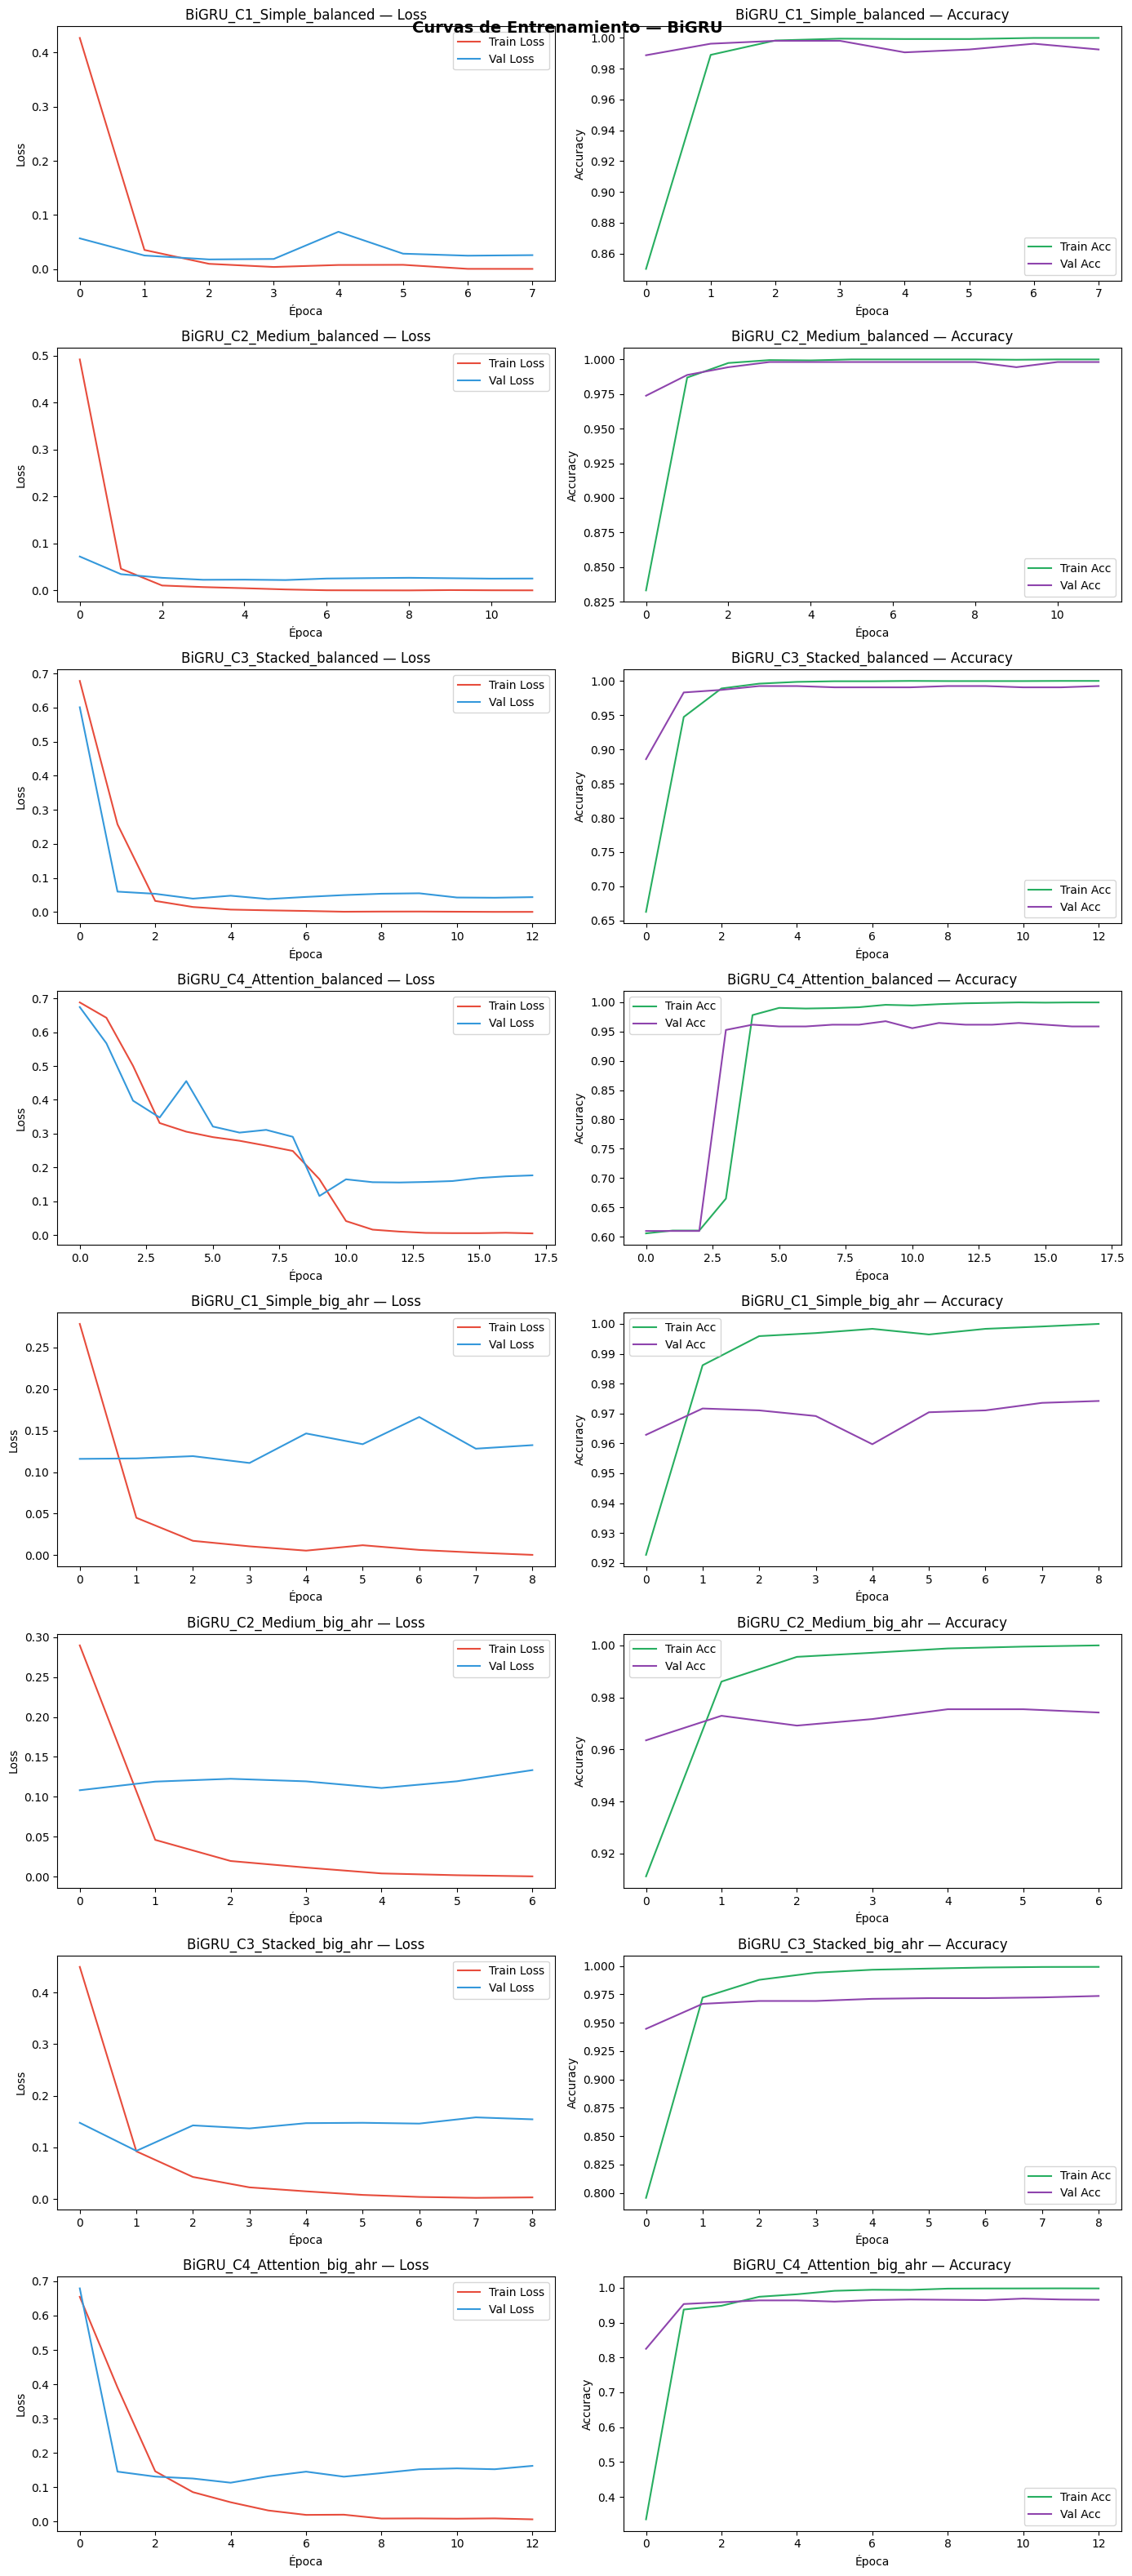

✅ results\figures\BiGRU_training_curves.png


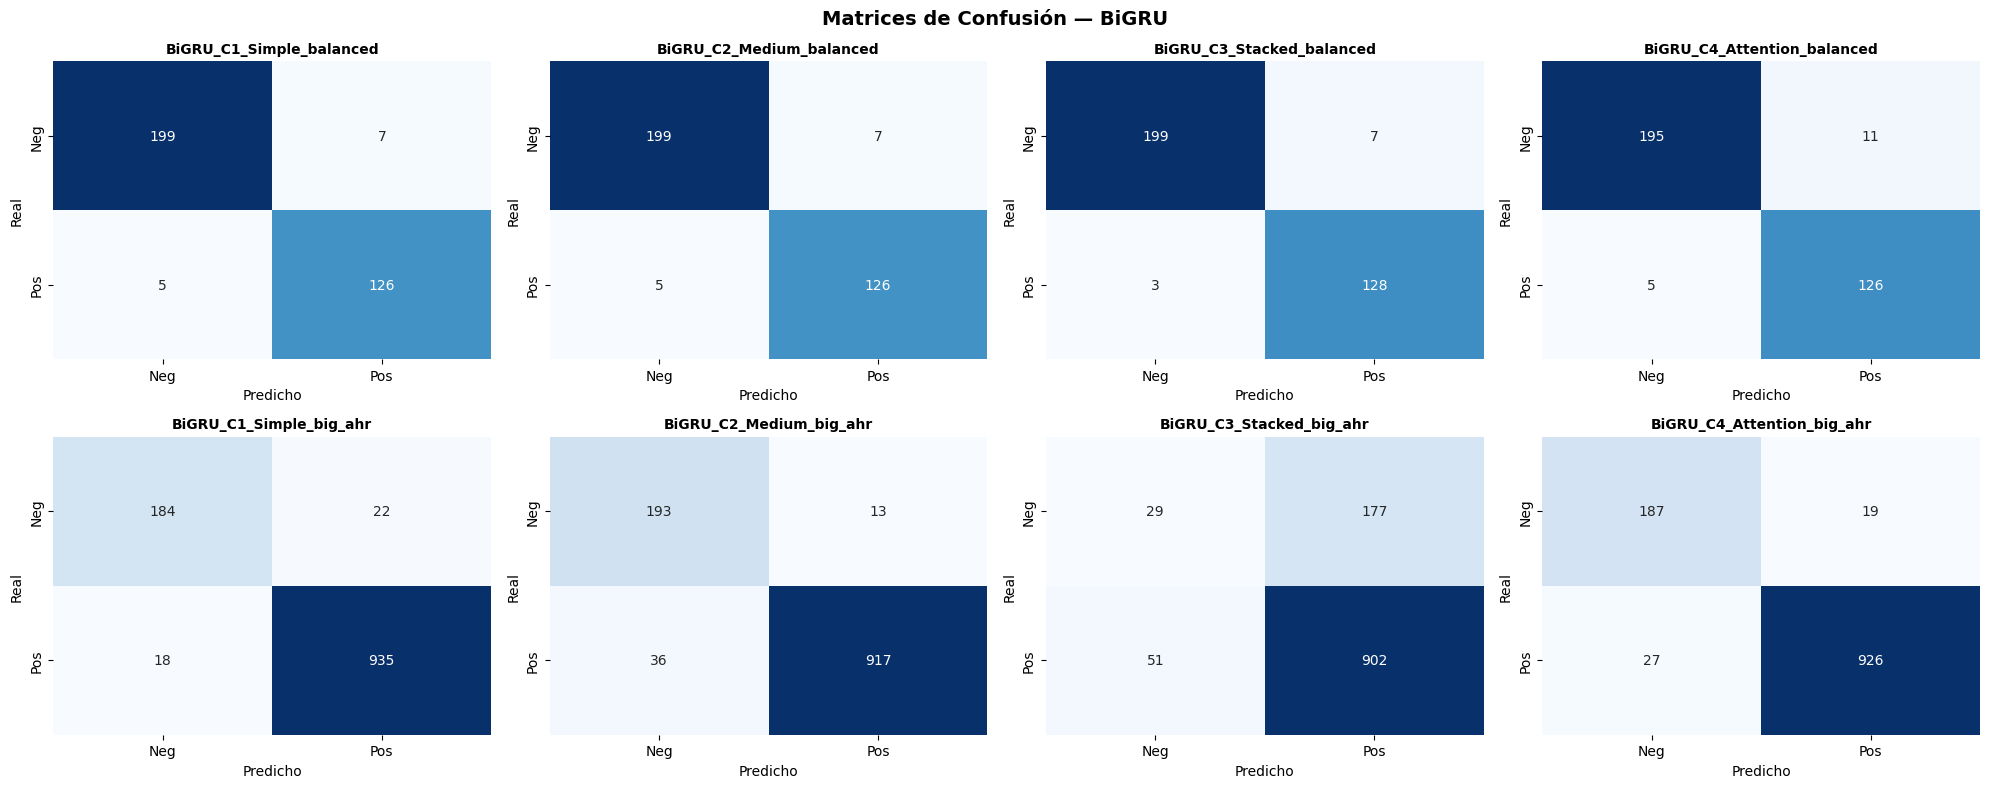

✅ results\figures\BiGRU_confusion_matrices.png


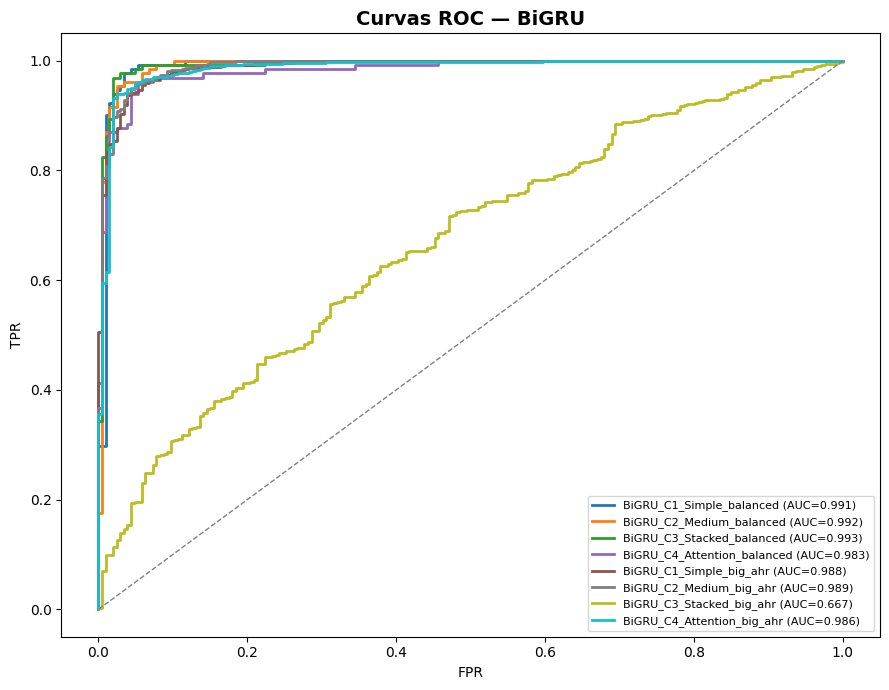

✅ Métricas guardadas: results\metrics\BiGRU_results.json

            Modelo  Dataset  Accuracy  Precision   Recall  F1-Score  ROC-AUC
   BiGRU_C1_Simple balanced  0.992523   0.985240 1.000000  0.992565 0.999874
   BiGRU_C2_Medium balanced  0.990654   0.988806 0.992509  0.990654 0.999860
  BiGRU_C3_Stacked balanced  0.990654   0.985185 0.996255  0.990689 0.999832
BiGRU_C4_Attention balanced  0.952522   0.919708 0.961832  0.940299 0.983102
   BiGRU_C1_Simple  big_ahr  0.981761   0.990895 0.987150  0.989019 0.994757
   BiGRU_C2_Medium  big_ahr  0.976730   0.990840 0.981104  0.985948 0.994814
  BiGRU_C3_Stacked  big_ahr  0.981132   0.990888 0.986395  0.988636 0.994944
BiGRU_C4_Attention  big_ahr  0.960311   0.979894 0.971668  0.975764 0.986140

✅ Tabla guardada: results\metrics\BiGRU_summary.csv


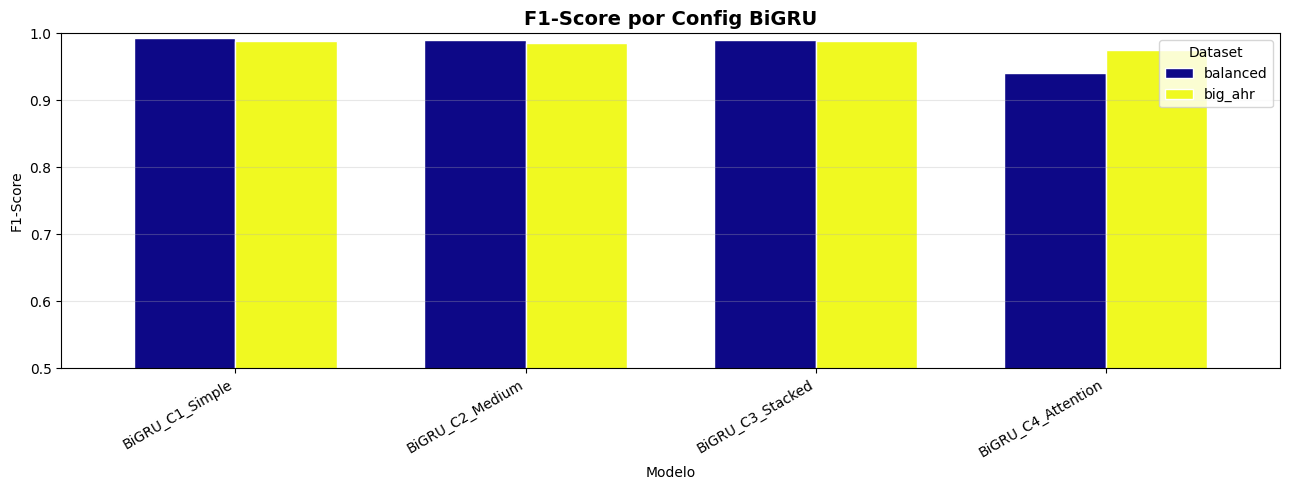

In [6]:
plot_training_curves(all_histories, "BiGRU")
plot_confusion_matrices(conf_matrix_data, "BiGRU")
plot_roc_curves(roc_data, "BiGRU")
save_metrics(all_results, "BiGRU")
df_summary = summarize_results(all_results, "BiGRU")

import pandas as pd
fig, ax = plt.subplots(figsize=(13, 5))
pivot = df_summary.pivot(index="Modelo", columns="Dataset", values="F1-Score")
pivot.plot(kind='bar', ax=ax, colormap='plasma', edgecolor='white', width=0.7)
ax.set_title("F1-Score por Config BiGRU", fontsize=14, fontweight='bold')
ax.set_ylabel("F1-Score"); ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title="Dataset"); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "BiGRU_f1_comparison.png"), dpi=130)
plt.show()